# Example solar power forecast

Here's a quick example of a solar power forecast using NOAA HRRR, NOAA GFS, and ECMWF IFS.

In [1]:
import matplotlib.pyplot as plt
from hefty.pv_model import model_pv_power
from hefty.solar import get_solar_forecast

Let's ignore xarray `FutureWarning`s (this should be addressed in Herbie before too long, see https://github.com/blaylockbk/Herbie/issues/525).

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# specs for a generic 100 MW solar plant, single-axis tracking, thin-film (truetracking)
latitude = 33.5
longitude = -86.8
mount_type = 'single-axis'
gcr = 0.4
nameplate_dc = 120
nameplate_ac = 100
dc_loss_fraction = 0.1
gamma_pdc = -0.003
shade_loss_model = 'linear'
backtrack = False
max_tracker_angle = 60

In [4]:
# get an intra-day forecast based on NOAA HRRR
init_date = '2024-06-05 6:00'
resource_data_hrrr = get_solar_forecast(
    latitude,
    longitude,
    init_date,
    run_length=18, # 18 hours are included in the forecast
    lead_time_to_start=3, # forecast starts 3 hours out from the init_date
    model='hrrr',
)
resource_data_hrrr['albedo'] = 0.2 # set a value for albedo

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jun-05 06:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jun-05 06:00 UTC F04 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jun-05 06:00 UTC F05 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jun-05 06:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jun-05 06:00 UTC F07 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jun-05 06:00 UTC F08 ┊ GRIB2 @ aws ┊ IDX @ 

In [5]:
resource_data_hrrr.head()

,point,temp_air,wind_speed,csi_ghi,csi_dni,ghi_clear,dni_clear,ghi,dni,dhi,albedo
valid_time,,,,,,,,,,,
2024-06-05 09:30:00+00:00,0,22.787605,2.675475,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.2
2024-06-05 10:30:00+00:00,0,22.600943,2.094798,0.142351,0.0,0.000000,0.000000,0.699282,0.0,0.699282,0.2
2024-06-05 11:30:00+00:00,0,22.500980,2.672233,0.373409,0.0,127.238898,573.291448,47.727026,0.0,47.727026,0.2
2024-06-05 12:30:00+00:00,0,22.818373,2.967941,0.431873,0.0,339.764476,782.816356,146.019695,0.0,146.019695,0.2
2024-06-05 13:30:00+00:00,0,23.233158,3.010693,0.315017,0.0,557.557582,882.984730,174.826547,0.0,174.826547,0.2


In [6]:
# model power using the forecasted resource data
power_ac_forecast_hrrr, resource_data_hrrr_updated = model_pv_power(
    resource_data=resource_data_hrrr,
    latitude=latitude,
    longitude=longitude,
    mount_type=mount_type,
    gcr=gcr,
    nameplate_dc=nameplate_dc,
    nameplate_ac=nameplate_ac,
    dc_loss_fraction=dc_loss_fraction,
    gamma_pdc=gamma_pdc,
    shade_loss_model=shade_loss_model,
    backtrack=backtrack,
    max_tracker_angle=max_tracker_angle,
)

<Axes: xlabel='valid_time'>

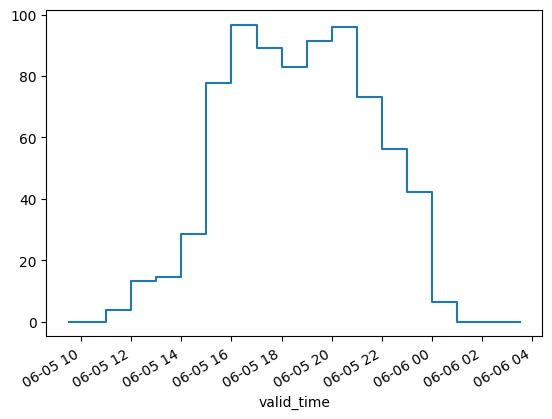

In [7]:
# plot the result
power_ac_forecast_hrrr.plot(drawstyle='steps-mid')

In [8]:
# get an intra-day forecast based on NOAA GFS
resource_data_gfs = get_solar_forecast(
    latitude,
    longitude,
    init_date,
    run_length=18, # 18 hours are included in the forecast
    lead_time_to_start=3, # forecast starts 3 hours out from the init_date
    model='gfs',
)
resource_data_gfs['albedo'] = 0.2 # set a value for albedo

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jun-05 06:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jun-05 06:00 UTC F04 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jun-05 06:00 UTC F05 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jun-05 06:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jun-05 06:00 UTC F07 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jun-05 

In [9]:
# model power using the forecasted resource data
power_ac_forecast_gfs, resource_data_gfs_updated = model_pv_power(
    resource_data=resource_data_gfs,
    latitude=latitude,
    longitude=longitude,
    mount_type=mount_type,
    gcr=gcr,
    nameplate_dc=nameplate_dc,
    nameplate_ac=nameplate_ac,
    dc_loss_fraction=dc_loss_fraction,
    gamma_pdc=gamma_pdc,
    shade_loss_model=shade_loss_model,
    backtrack=backtrack,
    max_tracker_angle=max_tracker_angle,
)

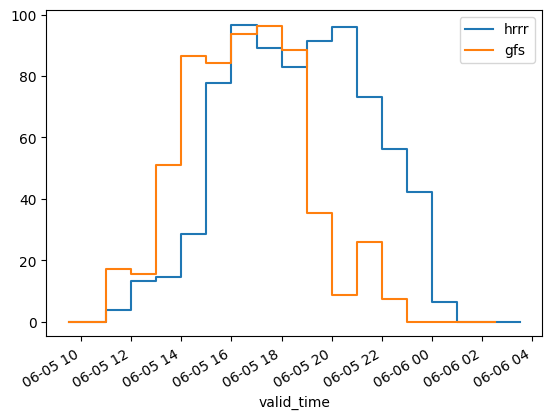

In [10]:
# plot the result
power_ac_forecast_hrrr.plot(label='hrrr', drawstyle='steps-mid')
power_ac_forecast_gfs.plot(label='gfs',drawstyle='steps-mid')
plt.legend()
plt.show()

In [11]:
# get an intra-day forecast based on NOAA GFS
resource_data_gefs = get_solar_forecast(
    latitude,
    longitude,
    init_date,
    run_length=18, # 18 hours are included in the forecast
    lead_time_to_start=3, # forecast starts 3 hours out from the init_date
    model='gefs',
    member='c00'
)
resource_data_gefs['albedo'] = 0.2 # set a value for albedo

✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Jun-05 06:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Jun-05 06:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Jun-05 06:00 UTC F09 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Jun-05 06:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Jun-05 06:00 UTC F15 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=gefs ┊ product=atmos.25 ┊ 2024-Jun-05 06:00 

In [12]:
# model power using the forecasted resource data
power_ac_forecast_gefs, resource_data_gefs_updated = model_pv_power(
    resource_data=resource_data_gefs,
    latitude=latitude,
    longitude=longitude,
    mount_type=mount_type,
    gcr=gcr,
    nameplate_dc=nameplate_dc,
    nameplate_ac=nameplate_ac,
    dc_loss_fraction=dc_loss_fraction,
    gamma_pdc=gamma_pdc,
    shade_loss_model=shade_loss_model,
    backtrack=backtrack,
    max_tracker_angle=max_tracker_angle,
)

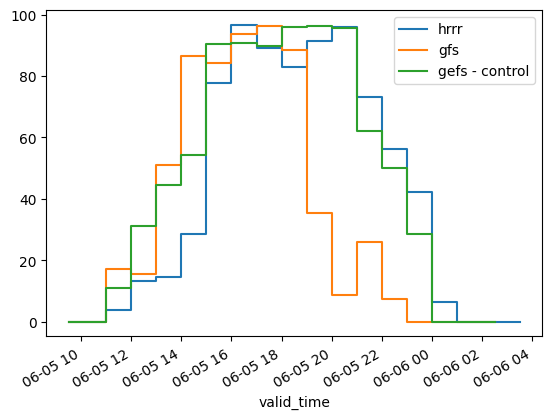

In [13]:
# plot the result
power_ac_forecast_hrrr.plot(label='hrrr', drawstyle='steps-mid')
power_ac_forecast_gfs.plot(label='gfs',drawstyle='steps-mid')
power_ac_forecast_gefs.plot(label='gefs - control',drawstyle='steps-mid')
plt.legend()
plt.show()

In [14]:
# get an intra-day forecast based on ECMWF IFS
resource_data_ifs = get_solar_forecast(
    latitude,
    longitude,
    init_date,
    run_length=18, # 18 hours are included in the forecast
    lead_time_to_start=3, # forecast starts 3 hours out from the init_date
    model='ifs',
)
resource_data_ifs['albedo'] = 0.2 # set a value for albedo

✅ Found ┊ model=ifs ┊ product=scda ┊ 2024-Jun-05 06:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=ifs ┊ product=scda ┊ 2024-Jun-05 06:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=ifs ┊ product=scda ┊ 2024-Jun-05 06:00 UTC F09 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=ifs ┊ product=scda ┊ 2024-Jun-05 06:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=ifs ┊ product=scda ┊ 2024-Jun-05 06:00 UTC F15 ┊ GRIB2 @ aws ┊ IDX @ aws
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=ifs ┊ product=scda ┊ 2024-Jun-05 06:00 UTC F18 ┊ GRIB2 @ aws ┊ IDX @ 

In [15]:
# model power using the forecasted resource data
power_ac_forecast_ifs, resource_data_ifs_updated = model_pv_power(
    resource_data=resource_data_ifs,
    latitude=latitude,
    longitude=longitude,
    mount_type=mount_type,
    gcr=gcr,
    nameplate_dc=nameplate_dc,
    nameplate_ac=nameplate_ac,
    dc_loss_fraction=dc_loss_fraction,
    gamma_pdc=gamma_pdc,
    shade_loss_model=shade_loss_model,
    backtrack=backtrack,
    max_tracker_angle=max_tracker_angle,
)

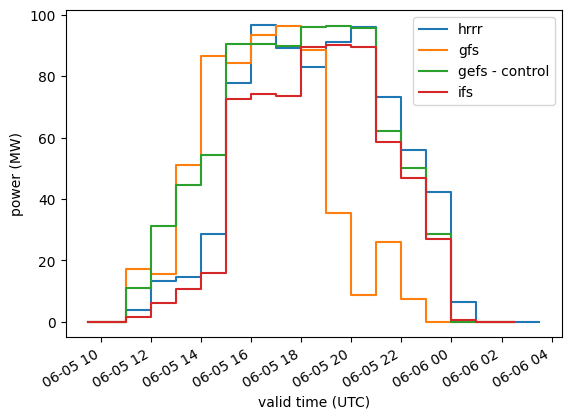

In [16]:
# plot the result
power_ac_forecast_hrrr.plot(drawstyle='steps-mid', label='hrrr')
power_ac_forecast_gfs.plot(drawstyle='steps-mid', label='gfs')
power_ac_forecast_gefs.plot(drawstyle='steps-mid', label='gefs - control')
power_ac_forecast_ifs.plot(drawstyle='steps-mid', label='ifs')
plt.legend()
plt.ylabel('power (MW)')
plt.xlabel('valid time (UTC)')
plt.show()

_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF), licensed under CC BY 4.0. © 2025 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0). To view a copy of this licence, visit https://creativecommons.org/licenses/by-nc-sa/4.0/. ECMWF does not accept any liability whatsoever for any error or omission in the data, their availability, or for any loss or damage arising from their use._

_ECMWF Data have been modified using the functions included in the hefty Python package (e.g., interpolation to hourly values)._